In [1]:
import pandas as pd

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
data_hf = pd.read_csv(url)

# Preview
data_hf.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [2]:
data_hf.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [3]:
data_hf.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [4]:
data_hf.duplicated().sum()

np.int64(0)

In [5]:
# Count males and females
data_hf['sex'].value_counts()

sex
1    194
0    105
Name: count, dtype: int64

In [6]:
# Filter non-smokers
non_smokers = data_hf[data_hf['smoking'] == 0]

non_smokers['sex'].value_counts()

sex
1    102
0    101
Name: count, dtype: int64

In [7]:
data_hf['age'].describe()

count    299.000000
mean      60.833893
std       11.894809
min       40.000000
25%       51.000000
50%       60.000000
75%       70.000000
max       95.000000
Name: age, dtype: float64

In [8]:
data_hf['age'].value_counts().idxmax()

np.float64(60.0)

In [9]:
data_hf['risk'] = data_hf.apply(
    lambda row: 'High' if row['age'] > 50 and row['serum_creatinine'] > 1.2 else 'Low',
    axis=1
)

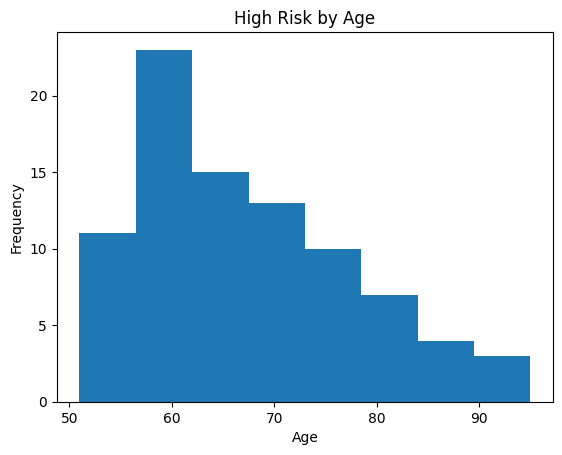

In [10]:
import matplotlib.pyplot as plt

high_risk = data_hf[data_hf['risk'] == 'High']

plt.hist(high_risk['age'], bins='auto')
plt.title('High Risk by Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

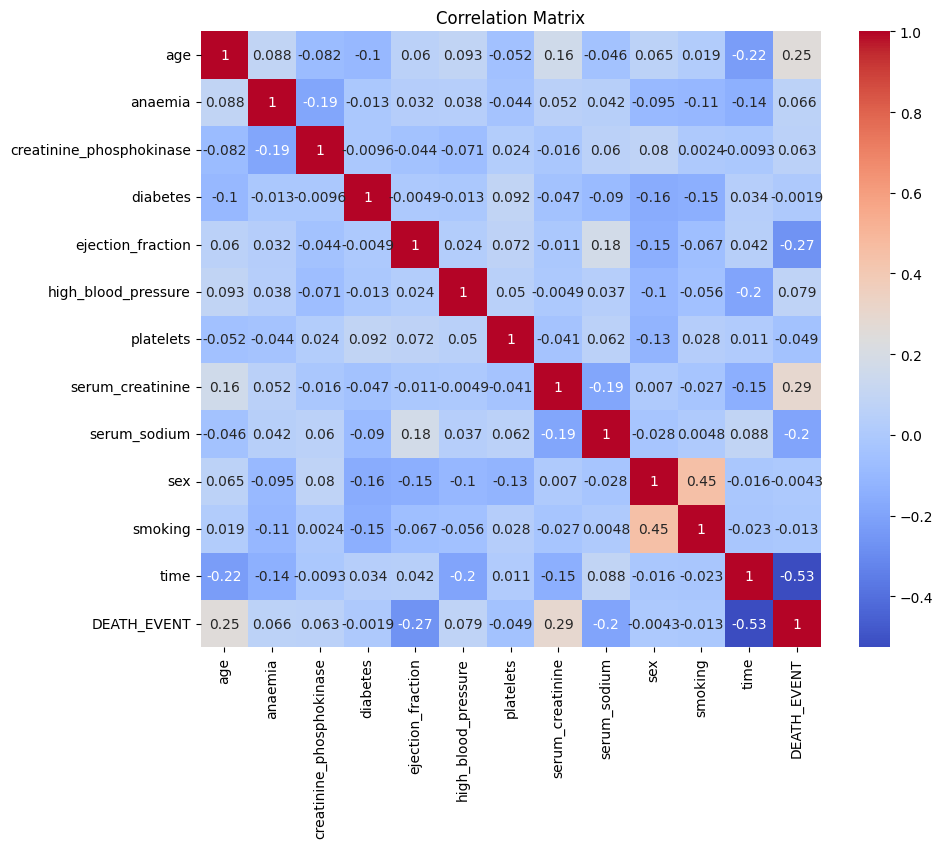

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = data_hf.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [14]:
corr.unstack().sort_values()

DEATH_EVENT          time                  -0.526964
time                 DEATH_EVENT           -0.526964
ejection_fraction    DEATH_EVENT           -0.268603
DEATH_EVENT          ejection_fraction     -0.268603
time                 age                   -0.224068
                                              ...   
high_blood_pressure  high_blood_pressure    1.000000
anaemia              anaemia                1.000000
time                 time                   1.000000
smoking              smoking                1.000000
DEATH_EVENT          DEATH_EVENT            1.000000
Length: 169, dtype: float64